In [1]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
pd.set_option('display.max_columns', None)
import time
import warnings
warnings.filterwarnings("ignore")
import os
import sys

In [2]:
import data_utils
import illume

In [3]:
from utils import xgb_eval, lgbm_eval, catb_eval
from expl_utils import inverse_transform_rule_complete

# Load Dataset

In [4]:
# dataset_name= 'adult'
dataset_name= 'compas'
# dataset_name= 'fico'
# dataset_name= 'churn'
# dataset_name= 'breast'

data_dict = data_utils.get_tabular_dataset(dataset_name, random_state=42)

In [5]:
X_train, X_test, y_train, y_test = data_dict['X_train'], data_dict['X_test'], data_dict['y_train'], data_dict['y_test']

In [6]:
features_map = data_dict['features_map']
idx_num_cat = [list(d.values()) for i,d in features_map.items()]

# Train Black-Box

In [7]:
clf, clf_score = lgbm_eval(X_train, y_train, X_test, y_test, n_iter=1, random_state=42)
print(clf_score)

0.5526535289336585


In [8]:
y_train_pred = clf.predict_proba(X_train)
y_test_pred = clf.predict_proba(X_test)

# Latent Encoding Training

### Run the code for training a dense meta-encoding.

In [ ]:
latent = illume.ILLUME(max_epochs=200, latent_dim=4, batch_size=2048, early_stopping=30)

Important inputs:
- X=(X_train, X_test) : train/validation sets for validation accuracy / early stopping
- y=(y_train_pred, y_test_pred) : predicted black-box probabilities (optional)
- idx_num_cat : list of lists with numerical/categorical features indices
- params_dict : dictionary with regularization parameters

Keys in params_dict:
- 'num_k': number of non-zero weights per row in the encoder transformation matrix. None means all non-zero weights  
- 'l_so': set to 1.0 to enable orthogonalization of the encoder transformation matrix (only if 'num_k'!= None) 
- 'l_rec': set to 1.0 to enable training a non-linear decoder 
- 'l_kld': set to 1.0 to optimize distances distribution
- 'l_co': set to 1.0 to optimize non-collinearity of latent features
- 'l_st': set to 1.0 to optimize local stability of individual linear transformations (only if encdec='param_encdec')

In [10]:
losses = latent.fit(X=(X_train, X_test),                   
                    y=(y_train_pred, y_test_pred),               
                    idx_num_cat=idx_num_cat,                       
                    params_dict={'num_k':None, 'l_rec':0.0, 'l_kld':1.0,      # dictionary with regularization parameters
                            'l_so':0.0, 'l_co':0.0, 'l_st':0.0},
                    seed=42)

num. parameters = 6331
Training Meta-encoder with max 200 iterations.


Epoch: 200 Train Loss 0.01604 Test Loss 0.01521 Early Stopping 0 

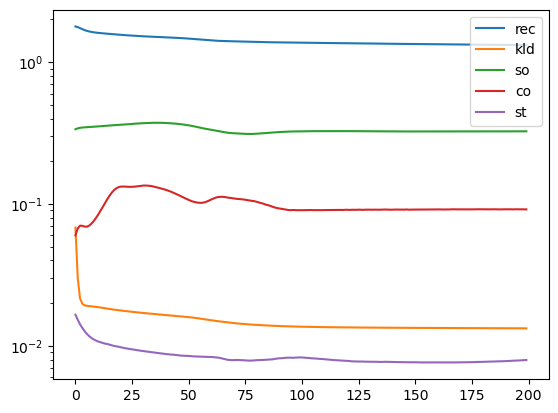

In [11]:
# plt.plot(np.array(losses[0])[:,:-1], label=['rec', 'kld', 'so', 'co', 'st'])
plt.plot(np.array(losses[1])[:,:-1], label=['rec', 'kld', 'so', 'co', 'st'])
plt.yscale('log')
plt.legend()

Text(0.5, 1.0, 'Space Z')

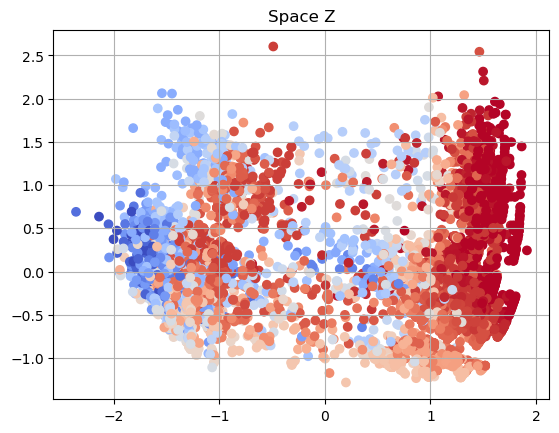

In [11]:
from sklearn.decomposition import PCA

Z = latent.Z_train.copy()
Y = latent.y_train[:, 1].copy()
Z = PCA().fit_transform(Z)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space Z')

Text(0.5, 1.0, 'Space W')

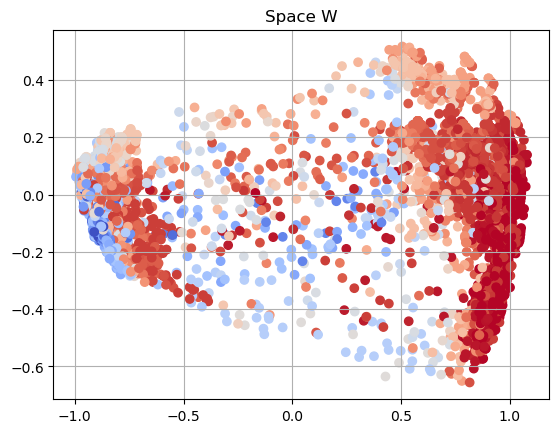

In [12]:
from sklearn.decomposition import PCA

W = latent.W_train.reshape(-1, np.prod(latent.W_train.shape[1:]))
Y = latent.y_train[:,1].copy()
Z = PCA().fit_transform(W)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space W')

# Local Explanations

In [13]:
y_train_bb = clf.predict(X_train)
y_test_bb = clf.predict(X_test)

### Feature importance

In [14]:
latent.explain_linear(num_k=None)

Training Logistic Regression surrogate.
LR surrogate score: 0.9766


In [15]:
fimp = latent.get_feature_importance(X_test, y_test_bb, num_k=None)

In [16]:
fimp = [[(att, ex[i]) for i,att in enumerate(data_dict['feature_names']) 
         if (ex[i]!=0.0) and (att in data_dict['numeric_columns'] or x[i]==1.)] if np.all(ex!=None) else None 
         for ex,x in zip(fimp, X_test)]

In [17]:
fimp[0]

[('age', np.float64(-0.11681758305871072)),
 ('priors_count', np.float64(-0.050492441349416065)),
 ('days_b_screening_arrest', np.float64(0.04566625770603902)),
 ('is_recid', np.float64(-0.15137466681075468)),
 ('is_violent_recid', np.float64(-0.03374920453350794)),
 ('two_year_recid', np.float64(-0.13716573122024586)),
 ('length_of_stay', np.float64(-0.07128439481818125)),
 ('age_cat=25 - 45', np.float64(0.34135150969732053)),
 ('sex=Male', np.float64(0.2873348840173333)),
 ('race=African-American', np.float64(0.3336696259965549)),
 ('c_charge_degree=M', np.float64(0.2962716906173088))]

### Decision Rules

In [18]:
latent.explain_dectree(num_k=2)

Training Decision Tree surrogate.
DT surrogate score: 0.9817


##### Factual rules

In [19]:
rules = latent.get_decision_rules(X_test, y_test_bb, num_k=2)

In [20]:
rules = [[(data_dict['feature_names'][int(att[1:])], op, val) 
          for (att, op), val in inverse_transform_rule_complete(ex, data_dict['scaler'], latent.idx_num).items()] if ex!=None else None  
          for ex in rules]

In [21]:
rules = [[(att, op, val) if att in data_dict['numeric_columns'] 
          else (att.split('=')[0], ('=' if op=='>' else '!='), att.split('=')[1]) 
          for att, op, val in ex] if ex!=None else None  
          for ex in rules]

In [22]:
rules[0]

[('two_year_recid', '<=', np.float64(0.2513708681766027)),
 ('race', '!=', 'Asian')]

##### Counterfactual rules/Counter-examples

In [ ]:
crules, cfs = latent.get_counterfactuals(X_test, y_test_bb, num_k=2)

In [ ]:
crules = [[[(data_dict['feature_names'][int(att[1:])], op , val) 
            for (att, op), val in inverse_transform_rule_complete(cx, data_dict['scaler'], latent.idx_num).items()] if cx!=None else None
            for cx in cx_list] for cx_list in crules]

In [ ]:
crules = [[[(att, op, val) if att in data_dict['numeric_columns'] 
          else (att.split('=')[0], ('=' if op=='>' else '!='), att.split('=')[1]) 
          for att, op, val in cx] if cx!=None else None 
          for cx in cx_list] for cx_list in crules]

In [ ]:
crules[0]

In [ ]:
cfs = [np.concatenate((data_dict['scaler'].inverse_transform(cf[:, latent.idx_num]), (cf[:, latent.idx_cat] if latent.idx_cat!=None else cf[:, :0])), axis=1) if np.any(cf!=None) else cf for cf in cfs]